In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nShape")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB
None

Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int

In [4]:
type_counts = df['type'].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


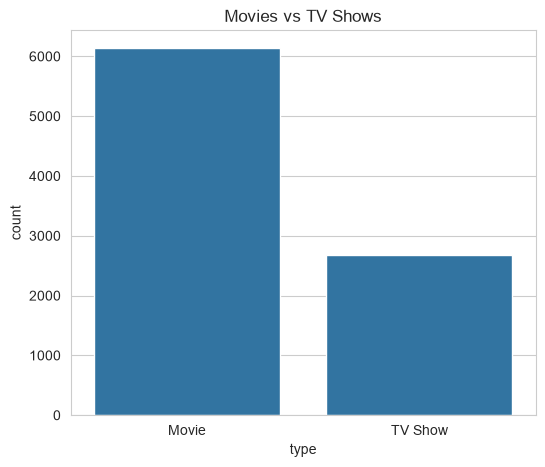

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows")
plt.show()

In [7]:
# Remove leading/trailing spaces
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

print(df[['date_added', 'year_added']].head())

  date_added  year_added
0 2021-09-25      2021.0
1 2021-09-24      2021.0
2 2021-09-24      2021.0
3 2021-09-24      2021.0
4 2021-09-24      2021.0


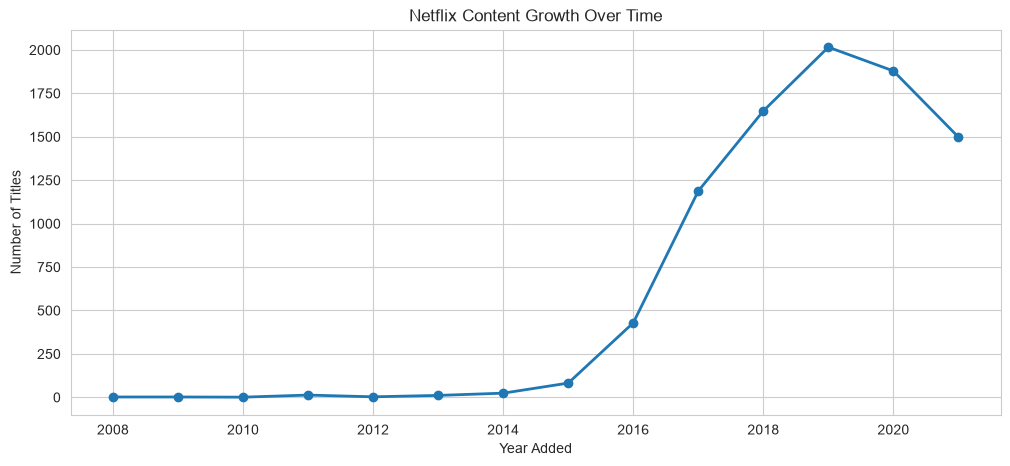

In [8]:
# Count content added each year
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12,5))

year_counts.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

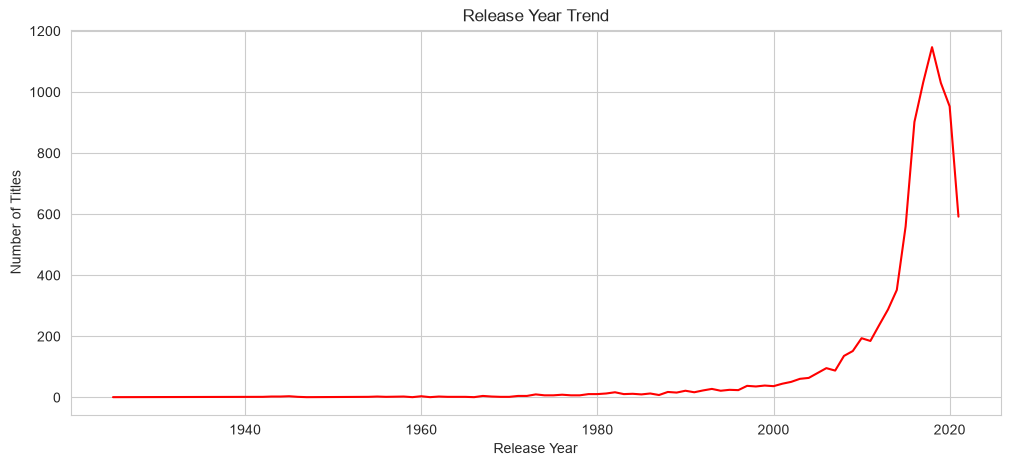

In [9]:
release_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

release_year.plot(
    kind='line',
    color='red'
)

plt.title("Release Year Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

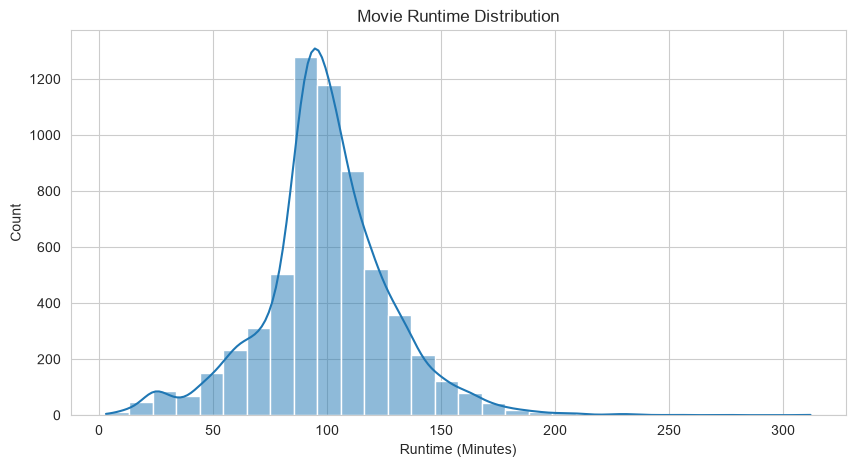

In [10]:
movies = df[df['type']=="Movie"].copy()

movies['duration'] = movies['duration'].str.replace(" min","", regex=False)

movies['duration'] = pd.to_numeric(
    movies['duration'],
    errors='coerce'
)

plt.figure(figsize=(10,5))

sns.histplot(
    movies['duration'],
    bins=30,
    kde=True
)

plt.title("Movie Runtime Distribution")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Count")

plt.show()

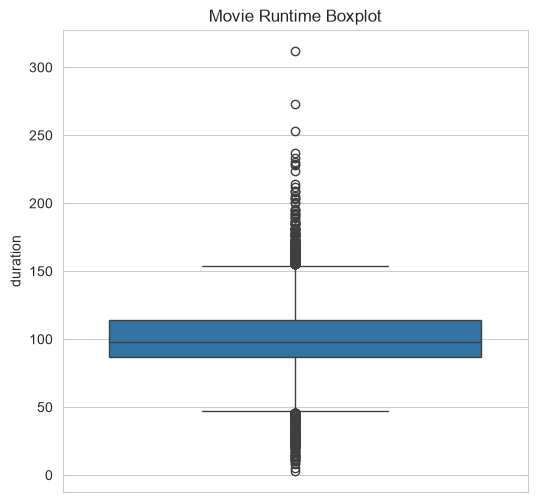

In [11]:
plt.figure(figsize=(6,6))

sns.boxplot(y=movies['duration'])

plt.title("Movie Runtime Boxplot")

plt.show()

In [12]:
genres = (
    df['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


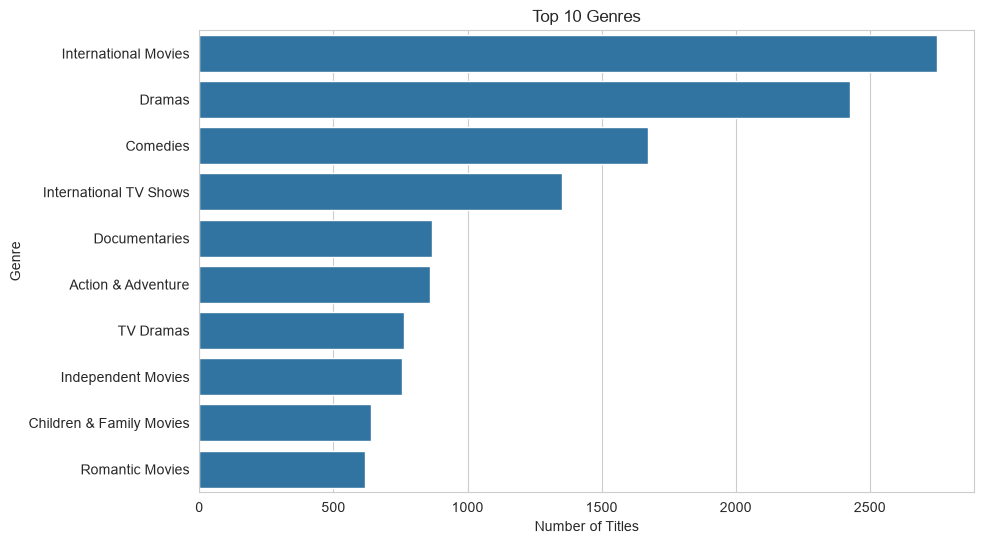

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [14]:
top_years = df['release_year'].value_counts().head(10)

print(top_years)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


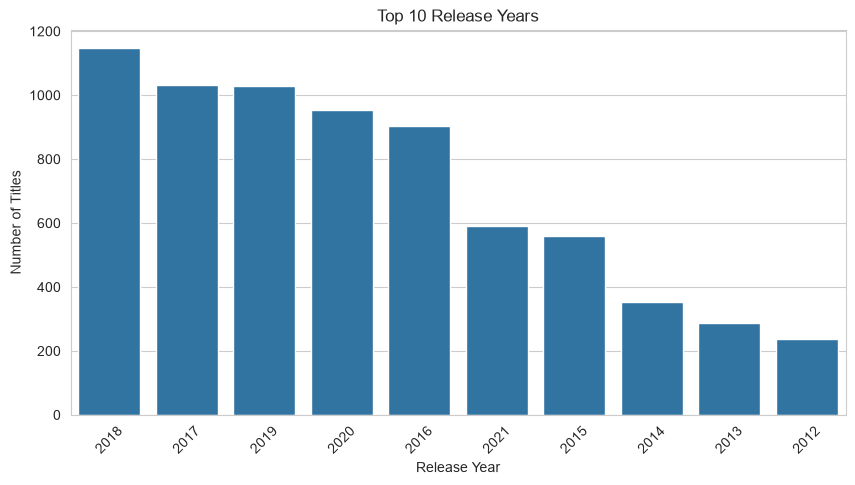

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_years.index.astype(str),
    y=top_years.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

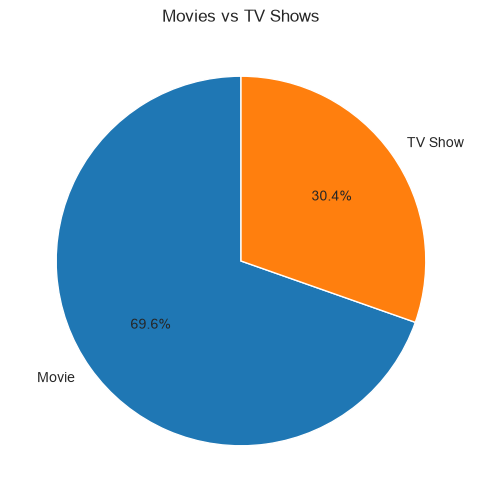

In [16]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.show()

In [17]:
plt.savefig("movies_vs_tv.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [18]:
plt.savefig("content_growth.png", dpi=300, bbox_inches='tight')
plt.savefig("release_year_trend.png", dpi=300, bbox_inches='tight')
plt.savefig("runtime_distribution.png", dpi=300, bbox_inches='tight')
plt.savefig("runtime_boxplot.png", dpi=300, bbox_inches='tight')
plt.savefig("top_genres.png", dpi=300, bbox_inches='tight')
plt.savefig("top_years.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [19]:
summary = pd.DataFrame({
    "Total Titles": [len(df)],
    "Movies": [(df['type']=="Movie").sum()],
    "TV Shows": [(df['type']=="TV Show").sum()],
    "Top Genre": [top_genres.index[0]],
    "Top Genre Count": [top_genres.iloc[0]],
    "Most Common Release Year": [top_years.index[0]]
})

summary.to_csv("Netflix_Summary_Report.csv", index=False)

print(summary)

   Total Titles  Movies  TV Shows             Top Genre  Top Genre Count  \
0          8807    6131      2676  International Movies             2752   

   Most Common Release Year  
0                      2018  
